# Building a Content Moderation Model with RLHF (SFT + DPO)
> Fine-tuning for toxicity detection using Supervised Fine-Tuning and Reinforcement Learning with Human Feedback

LLaMA 3.2-1B | Laptop RTX 4070 (8GB) | Civil Comments Dataset

## Results

| Model | PR-AUC | ROC-AUC |
|-------|--------|---------|
| Base | 0.223 | 0.648 |
| + SFT | 0.729 | 0.924 |
| + DPO | 0.752 | 0.931 |


**Precision at Fixed Recall** 
| Recall | Base | SFT | DPO |
|--------|------|-----|-----|
| 95% | 17% | 33% | 35% |
| 90% | 17% | 41% | 44% |
| 80% | 19% | 52% | 55% |

**TL;DR:** Trained a lightweight toxicity scorer by fine-tuning LLaMA 3.2-1B on a single RTX 4070. SFT learns the classification task by improving PR-AUC from 0.22 to 0.73, while DPO provides a smaller but consistent gain to 0.75, primarily by increasing confidence on non-toxic content. The resulting score is continuous and thresholdable, enabling multiple moderation policies from a single model.

## What I'm Building

The system is intentionally trained as a calibrated continuous scoring function rather than a hard classifier to learn a continuous toxicity scoring function that can support different moderation policies via score thresholding.

Content moderation isn't binary. Different platforms need different thresholds. For example, a kids' platform wants to catch everything and an adult platform wants to avoid false flags.

**The Pipeline**
1. SFT: teaches the format of the task and concentrates the probability mass onto the labels of "toxic" and "not toxic", making the RLHF step more efficient. After SFT: $P(y = \text{toxic} \mid x_{\text{train}})+ P(y = \text{non-toxic} \mid x_{\text{train}}) \approx 1$ (induced by the data, not enforced by the objective), so the log-prob difference approximates a log-odds score.
2. DPO: main finetuning step, maximize a ratio of probabilities, increasing the log-odds of an accepeted preference relative to a rejected one. We turn what was approximately a classifier into a ranker, making log-probability difference a natural choice for a score.


Constraints: Single RTX 4070 (8GB), so 4-bit quantization + LoRA. Standard techniques for memory-limited fine-tuning.

Evaluation: PR-AUC over accuracy (85% of data is non-toxic, so accuracy is meaningless).

In [2]:
# Core imports
import os
import gc
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# HuggingFace
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM, 
    AutoTokenizer, 
    BitsAndBytesConfig
)
from peft import LoraConfig, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig, DPOTrainer, DPOConfig

# Sklearn
from sklearn.metrics import (
    precision_recall_curve, 
    roc_curve, 
    auc,
    precision_score,
    recall_score,
    confusion_matrix
)

def clear_memory():
    """Clear GPU memory between training runs."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

clear_memory()

# Verify GPU
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
VRAM: 8.6 GB


In [3]:
import yaml
from dataclasses import dataclass, asdict
from typing import Optional

@dataclass
class Config:
    """Centralized configuration for the RLHF pipeline."""
    
    # Model
    model_id: str = "meta-llama/Llama-3.2-1B-Instruct"
    
    # Data
    dataset_name: str = "google/civil_comments"
    toxic_threshold: float = 0.3  # Comments with toxicity >= this are labeled toxic
    sft_train_samples: int = 8000
    sft_eval_samples: int = 1000
    dpo_train_samples: int = 10000
    dpo_eval_samples: int = 1000
    test_samples: int = 40000  # For final evaluation, can be 10,000 but I wanted very high resolution PR curves
    
    # Quantization (for 8GB VRAM)
    load_in_4bit: bool = True
    bnb_4bit_quant_type: str = "nf4"
    bnb_4bit_use_double_quant: bool = True
    
    # LoRA
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05
    lora_target_modules: tuple = ("q_proj", "k_proj", "v_proj", "o_proj")
    
    # SFT Training
    sft_output_dir: str = "checkpoints/sft"
    sft_epochs: int = 1
    sft_batch_size: int = 1
    sft_gradient_accumulation: int = 16
    sft_learning_rate: float = 2e-4
    sft_max_length: int = 256
    sft_warmup_ratio: float = 0.03
    
    # DPO Training
    dpo_output_dir: str = "checkpoints/dpo"
    dpo_epochs: int = 1
    dpo_batch_size: int = 1
    dpo_gradient_accumulation: int = 16
    dpo_learning_rate: float = 5e-5
    dpo_beta: float = 0.1
    dpo_max_length: int = 256
    dpo_max_prompt_length: int = 224
    
    # Paths
    sft_adapter_path: str = "checkpoints/sft/final"
    dpo_adapter_path: str = "checkpoints/dpo/final"
    data_dir: str = "data"
    results_dir: str = "results"
    figures_dir: str = "figures"
    
    # Random seed
    seed: int = 67
    
    def save(self, path: str):
        """Save config to YAML file."""
        with open(path, 'w') as f:
            yaml.dump(asdict(self), f, default_flow_style=False)
    
    @classmethod
    def load(cls, path: str):
        """Load config from YAML file."""
        with open(path, 'r') as f:
            return cls(**yaml.safe_load(f))

# Initialize config
config = Config()

# Save for reproducibility
config.save('config/config.yaml')
print("Configuration:")
print(yaml.dump(asdict(config), default_flow_style=False))

# Create directories
for dir_path in [config.data_dir, config.results_dir, config.figures_dir]:
    os.makedirs(dir_path, exist_ok=True)

# For adapter paths, create parent directories (checkpoints/sft, checkpoints/dpo)
os.makedirs(os.path.dirname(config.sft_adapter_path), exist_ok=True)
os.makedirs(os.path.dirname(config.dpo_adapter_path), exist_ok=True)

Configuration:
bnb_4bit_quant_type: nf4
bnb_4bit_use_double_quant: true
data_dir: data
dataset_name: google/civil_comments
dpo_adapter_path: checkpoints/dpo/final
dpo_batch_size: 1
dpo_beta: 0.1
dpo_epochs: 1
dpo_eval_samples: 1000
dpo_gradient_accumulation: 16
dpo_learning_rate: 5.0e-05
dpo_max_length: 256
dpo_max_prompt_length: 224
dpo_output_dir: checkpoints/dpo
dpo_train_samples: 10000
figures_dir: figures
load_in_4bit: true
lora_alpha: 32
lora_dropout: 0.05
lora_r: 16
lora_target_modules: !!python/tuple
- q_proj
- k_proj
- v_proj
- o_proj
model_id: meta-llama/Llama-3.2-1B-Instruct
results_dir: results
seed: 67
sft_adapter_path: checkpoints/sft/final
sft_batch_size: 1
sft_epochs: 1
sft_eval_samples: 1000
sft_gradient_accumulation: 16
sft_learning_rate: 0.0002
sft_max_length: 256
sft_output_dir: checkpoints/sft
sft_train_samples: 8000
sft_warmup_ratio: 0.03
test_samples: 40000
toxic_threshold: 0.3



## The Data

I initially considered Jigsaw unintended bias dataset while browsing HuggingFace but a lot of the labels could have be predicted from pretty obvious slurs. This is good for reducing how many slurs there are but RLHF designed to be specifically for problems with context and ambiguity so I kept searching.

I eventually came across the Civil Comments Dataset which has pretty ambiguous labels like "insult", "threat" and "toxicity" which makes it perfect for fine tuning with human preferences. Subjective judgment makes it a better fit for RLHF. 

Below is what the dataset looks like:

Each category has a float32 going from 0.0 to 1.0 rating averaged from multiple annotators. You can think of each score as estimating the probability that an annotator would label the comment as toxic rather than a hard ground truth label or "an estimator of the underlying probability that a randomly sampled annotator would assign that label to the comment". 


Our finetuning will increase the liklihood of responses consistent with the dataset so it's important to know where and when it's from. Here's what it says on the Dataset Summary: 
>**<center>"The comments in this dataset come from an archive of the Civil Comments platform, a commenting plugin for independent news sites. These public comments were created from 2015 - 2017 and appeared on approximately 50 English-language news sites across the world."</center>**

The annotations themselves were done in 2018-2019 and the comments are about a decade old. By finetuning our model on this dataset, we would basically teach our model to react like 2018-2019 annotators to 2015-2017 style comments. The dates shouldn't matter too much for this dataset since it's still relatively recent. It's important to at least know what your data is since high quality data is one of the most important aspects to finetuning.

In [3]:
# Load Civil Comments dataset (https://huggingface.co/datasets/google/civil_comments)
dataset = load_dataset(config.dataset_name)

print(f"Dataset splits: {list(dataset.keys())}")

Dataset splits: ['train', 'validation', 'test']


In [4]:
print(f"Train size: {len(dataset['train']):,}")
print(f"Validation size: {len(dataset['validation']):,}")
print(f"Test size: {len(dataset['test']):,}")
print(f"\nFeatures: {list(dataset['train'].features.keys())}")

Train size: 1,804,874
Validation size: 97,320
Test size: 97,320

Features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit']


The dataset is massive, 1.8 M just in the training, but we definitely won't need all of it. Llama's base model is great already ~10k is a good amount that will allow us to get slightly more preference tuning.

For simplicity, I decided to just analyze the "toxicity" label for this project but this analysis can easily be scaled to the other labels using a weighted score.

### Choosing a toxicity threshold of 0.3

<Figure size 640x480 with 0 Axes>

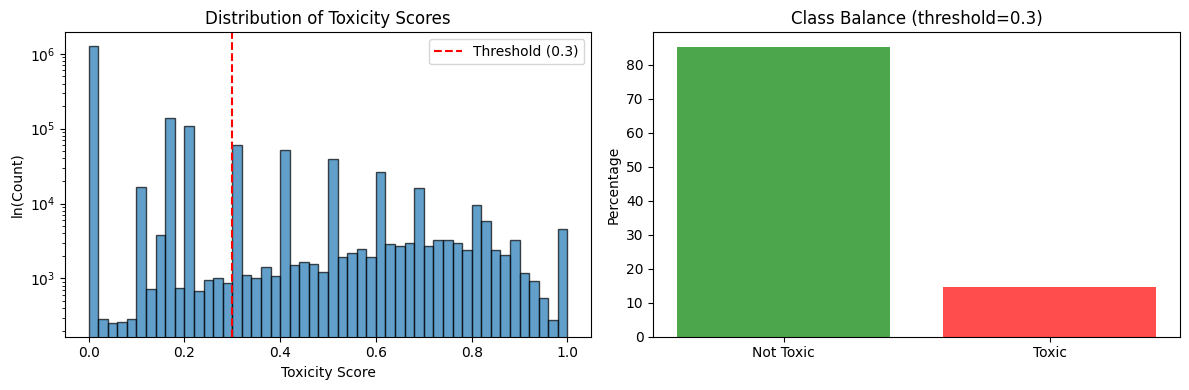

At threshold 0.3: 14.7% toxic, 85.3% not toxic


In [191]:
# Now let's see the distributions of the scores
train_toxicity = np.array(dataset['train']['toxicity'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
# nonzero_toxicity = train_toxicity[train_toxicity > 0] # Exclude zero-toxicity mass for visualization clarity
axes[0].hist(train_toxicity, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(config.toxic_threshold, color='red', linestyle='--', label=f'Threshold ({config.toxic_threshold})')
axes[0].set_xlabel('Toxicity Score')
axes[0].set_ylabel('ln(Count)')
axes[0].set_yscale('log')
axes[0].set_title('Distribution of Toxicity Scores')
axes[0].legend()

# Class balance at our threshold
toxic_pct = (train_toxicity >= config.toxic_threshold).mean() * 100
axes[1].bar(['Not Toxic', 'Toxic'], [100-toxic_pct, toxic_pct], color=['green', 'red'], alpha=0.7)
axes[1].set_ylabel('Percentage')
axes[1].set_title(f'Class Balance (threshold={config.toxic_threshold})')

plt.savefig(f'{config.figures_dir}/data_distribution.png', dpi=300)
plt.tight_layout()
plt.show()



print(f"At threshold {config.toxic_threshold}: {toxic_pct:.1f}% toxic, {100-toxic_pct:.1f}% not toxic")

The data is actually made up of two distributions with most comments being not toxic:
- Many low toxicity, cheaply annotated comments that have more discrete intervals
- Some high toxicity, heavily reviewed comments that seem to be averaged out amongst many reviewers

Some of the lines are binning artifacts but because there are over a hundred times more decile labels than in between for scores such as 0.2, this explanation makes more sense. I also had to make the y-axis logarithmic to show scores like 0 without distorting the high toxicity distribution.

Since we will be training the model for binary outputs, we have to choose the toxicity level we want to split the data from "toxic" and "not toxic". Above the toxicity threshold, we will call a label "toxic" and right below it we will call it "not toxic" It defines what our model thinks is toxic or not.

Choosing a toxicity threshold is probably one of the most important part of this pipeline. If we define a threshold where we let through comments with things we don't like, the model will classify them as not toxic and this will make our metrics look way better than what we wanted.

At some point in the pipeline, we have to eventually define a threshold of what's toxic or not anyways, let's pick 0.3 and see what kind of comments are around it.

Examples of comments:

In [165]:
# Sample comments to see what we're dealing with
print("Sample VERY TOXIC (> 0.8) comments:")
print("-" * 50)
for ex in dataset['train'].filter(lambda x: x['toxicity'] >= 0.8).select(range(3)):
    print(f"[{ex['toxicity']:.2f}] {ex['text'][:120]}...\n")

print("Sample ABOVE BOUNDARY (0.3 to 0.4)TOXIC comments:")
print("-" * 50)
for ex in dataset['train'].filter(lambda x: x['toxicity'] >= config.toxic_threshold and x['toxicity'] <= config.toxic_threshold+ .1).select(range(3)):
    print(f"[{ex['toxicity']:.2f}] {ex['text'][:120]}...\n")
print("Sample BELOW BOUNDARY (0.2 to 0.3)TOXIC comments:")
print("-" * 50)
for ex in dataset['train'].filter(lambda x: x['toxicity'] >= config.toxic_threshold -.1 and x['toxicity'] <= config.toxic_threshold).select(range(3)):
    print(f"[{ex['toxicity']:.2f}] {ex['text'][:120]}...\n")

print("\nSample NON-TOXIC (< 0.1)comments:")
print("-" * 50)
for ex in dataset['train'].filter(lambda x: x['toxicity'] < 0.1).select(range(3)):
    print(f"[{ex['toxicity']:.2f}] {ex['text'][:120]}...\n")

Sample VERY TOXIC (> 0.8) comments:
--------------------------------------------------
[0.89] haha you guys are a bunch of losers....

[0.91] Yet call out all Muslims for the acts of a few will get you pilloried.   So why is it okay to smear an entire religion o...

[0.83] This bitch is nuts. Who would read a book by a woman....

Sample ABOVE BOUNDARY (0.3 to 0.4)TOXIC comments:
--------------------------------------------------
[0.30] Mormons have had a complicated relationship with federal law....

[0.36] Send more dildos, STAT....

[0.30] I couldn't be more pleased. Comments on many sites too often get overtaken by trolls. It's the first I've heard of Civil...

Sample BELOW BOUNDARY (0.2 to 0.3)TOXIC comments:
--------------------------------------------------


Filter:   0%|          | 0/1804874 [00:00<?, ? examples/s]

[0.20] I'm crazy about that illustration! I never would have thought to pitch everything so yellow and orange....

[0.20] Thank you, thank you, thank you! I love WW content but the comment section has polluted for far too long. The lack of co...

[0.20] I think Native Americans should get a pass for being suspicious of any part of this government for the next… forever....


Sample NON-TOXIC (< 0.1)comments:
--------------------------------------------------
[0.00] This is so cool. It's like, 'would you want your mother to read this??' Really great idea, well done!...

[0.00] Thank you!! This would make my life a lot less anxiety-inducing. Keep it up, and don't let anyone get in your way!...

[0.00] This is such an urgent design problem; kudos to you for taking it on. Very impressive!...



Good thing we checked right above and right below 0.3. Right above 0.3, we get comments sarcastic comments about Mormons, dildos, and trolls. I would not want any of that for my [kid safe mode](#kidsafemode).

Eventually we need to discretize into "allow", "remove", and possibly even "review" bins. Seems like the toxicity threshold of around 0.3 is pretty decent but it's somewhat an arbitrary hyperparameter depending on how strict you want to be. We'll get to why this wouldn't be a problem if we pick the right metric in a bit but let's look at some graphs first.

## Evaluation Methods

### The Naive Method
The naive way to score the models would be to see how accurately it matches the distribution we fed in. (For example, does the output model mark 85.3% percent of the responses as nontoxic?)

This approach lacks dimensionality in proving that it understands and is easily reward hacked. The easiest way to achieve this would be to just literally mark every single response as "not toxic". This model will get 85.3% of the responses right.

### Why use Log-Probabilities as a Metric?

The log probability metric is inspired by what DPO does by maximizing the difference in log-probabilities between outputs

$$
\text{score} = log(P(y = \text{toxic} \mid \text{prompt}))-log(P(y = \text{non-toxic} \mid \text{prompt}))
$$

Why probabilities? Since the LLM outputs a distribution of possible next words through logits, probability is an obvious choice.

Why log? Mapping to log space has the nice property of turning ratios into differences. By subtracting the log probabilities, the metric allows us to compare the relative confidence of two outputs. We have the nice extension of being able to also measure the confidence in the model's decisions.


Using some log rules we get:

$$
e^{\text{score}} = \frac{P(\text{"toxic"} \mid x)}{P(\text{"not toxic"} \mid x)}
$$

This score map our binary outcome into a continuous number going from -inf to inf that represents how many more times the model thinks the comment is "toxic" than "toxic" with:
- positive score = model thinks toxic
- negative score = model thinks not toxic
- magnitude of score = confidence

A score of 1 means the model is ~2.718(or e) times more confident that the answer is "toxic" vs "not toxic".

A score of -1 means the model is ~2.718(or e) times more confident that the answer is "not toxic" vs "toxic".

### Data Preparation

We need two dataset formats:
1. **SFT format**: `{prompt, completion}` pairs
2. **DPO format**: `{prompt, chosen, rejected}` triplets
   
We'll prepare the data so that the only output is "toxic" or "not toxic". We'll also keep the outputs lowercase for convenience.

**Complete SFT Format**

Is this comment toxic? Answer only 'toxic' or 'not toxic'.

Comment: What's your favorite day of the week?

Answer: not toxic

**Complete DPO Format**

Is this comment toxic? Answer only 'toxic' or 'not toxic'.

Comment: What's your favorite day of the week?

Answer: not toxic

Rejected: toxic

In [7]:
def format_sft_example(example, toxic_threshold=0.3):
    """Convert to SFT format with binary label."""
    label = 'toxic' if example['toxicity'] >= toxic_threshold else 'not toxic'
    prompt = (
        f"Is this comment toxic? Answer only 'toxic' or 'not toxic'.\n\n"
        f"Comment: {example['text']}\n\n"
        f"Answer:"
    )
    return {'prompt': prompt, 'completion': f' {label}'}


def format_dpo_example(example, toxic_threshold=0.3):
    """Convert to DPO format with chosen/rejected responses."""
    is_toxic = example['toxicity'] >= toxic_threshold
    prompt = (
        f"Is this comment toxic? Answer only 'toxic' or 'not toxic'.\n\n"
        f"Comment: {example['text']}\n\n"
        f"Answer:"
    )
    if is_toxic:
        return {'prompt': prompt, 'chosen': ' toxic', 'rejected': ' not toxic'}
    else:
        return {'prompt': prompt, 'chosen': ' not toxic', 'rejected': ' toxic'}

For SFT I picked 8k since it's just learning the output format. The base model itself already has decent language understanding. For DPO I picked slightly more at 10k because preference learning benefits from more examples, especially on borderline cases. The validation is not really needed but 1k should be enough for sanity checks.

Now let's actually prepare the datasets and store them. The final test set looks like the SFT format so we will be making that here as well:

In [8]:
# Prepare SFT datasets
train_sft = dataset['train'].shuffle(seed=config.seed).select(range(config.sft_train_samples))
train_sft = train_sft.map(lambda x: format_sft_example(x, config.toxic_threshold), 
                          remove_columns=dataset['train'].column_names)

eval_sft = dataset['validation'].shuffle(seed=config.seed).select(range(config.sft_eval_samples))
eval_sft = eval_sft.map(lambda x: format_sft_example(x, config.toxic_threshold),
                      remove_columns=dataset['validation'].column_names)

# For final testing and analysis
test = dataset['test'].shuffle(seed=config.seed).select(range(config.test_samples))
test = test.map(lambda x: format_sft_example(x, config.toxic_threshold),
                      remove_columns=dataset['test'].column_names)

# Save for later
train_sft.to_json(os.path.join(config.data_dir, 'civil_comments_sft_train.jsonl'))
eval_sft.to_json(os.path.join(config.data_dir, 'civil_comments_sft_eval.jsonl'))
test.to_json(os.path.join(config.data_dir, 'civil_comments_test.jsonl'))

print(f"SFT train: {len(train_sft):,} | SFT eval: {len(eval_sft):,}| Test: {len(test):,}")
print(f"\nSample: {train_sft[0]}")

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Creating json from Arrow format:   0%|          | 0/8 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/40 [00:00<?, ?ba/s]

SFT train: 8,000 | SFT eval: 1,000| Test: 40,000

Sample: {'prompt': "Is this comment toxic? Answer only 'toxic' or 'not toxic'.\n\nComment: Nope, move the business to the US, live in Erie.  Pretty simple really, best of both worlds, keep my money and live in Canada. \n\nI guess that's too hard for a civil servant to figure out.\n\nAnswer:", 'completion': ' not toxic'}


In [9]:
# Prepare DPO datasets
train_dpo = dataset['train'].shuffle(seed=config.seed+1).select(range(config.dpo_train_samples))
train_dpo = train_dpo.map(lambda x: format_dpo_example(x, config.toxic_threshold),
                          remove_columns=dataset['train'].column_names)

eval_dpo = dataset['validation'].shuffle(seed=config.seed+2).select(range(config.dpo_eval_samples))
eval_dpo = eval_dpo.map(lambda x: format_dpo_example(x, config.toxic_threshold),
                      remove_columns=dataset['validation'].column_names)

train_dpo.to_json(os.path.join(config.data_dir, 'civil_comments_dpo_train.jsonl'))
eval_dpo.to_json(os.path.join(config.data_dir, 'civil_comments_dpo_eval.jsonl'))

print(f"DPO train: {len(train_dpo):,} | DPO eval: {len(eval_dpo):,}")
print(f"\nSample: {train_dpo[0]}")

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Creating json from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

DPO train: 10,000 | DPO eval: 1,000

Sample: {'prompt': "Is this comment toxic? Answer only 'toxic' or 'not toxic'.\n\nComment: KKK + Nazi's = President winner winner chicken dinner.\n\nAnswer:", 'chosen': ' not toxic', 'rejected': ' toxic'}


Nice, that's the format we wanted.

Now let's see what the untrained LLaMA wants to output after the prompt:

In [10]:
# Load base model
model = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(config.model_id)
tokenizer.pad_token = tokenizer.eos_token

print(f"Loaded {config.model_id}")
print(f"Parameters: {model.num_parameters():,}")

Loaded meta-llama/Llama-3.2-1B-Instruct
Parameters: 1,235,814,400


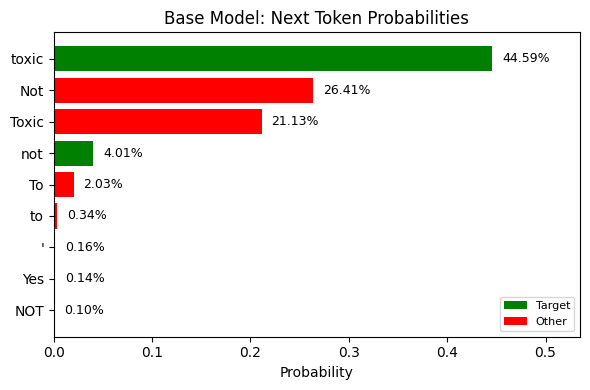

Base model: P(toxic)=0.4459, P(not)=0.0401, sum=0.4860


In [11]:
from src.scoring import plot_top_token_probs, get_label_probs

# Test on sample prompt
sample_prompt = eval_sft[0]['prompt']

# Base model
fig = plot_top_token_probs(model, tokenizer, sample_prompt, title="Base Model: Next Token Probabilities")
plt.savefig(f'{config.figures_dir}/base_token_probs.png', dpi=150)
plt.show()

# Print the probability of labels
p_toxic, p_not = get_label_probs(model, tokenizer, sample_prompt)
print(f"Base model: P(toxic)={p_toxic:.4f}, P(not)={p_not:.4f}, sum={p_toxic+p_not:.4f}")

The base model’s probability mass is spread across vocabulary. The next token is not what we want in more than half of the cases, confirming the need for finetuning.

## SFT Training

First, let's clear our VRAM and load something with better memory management:

In [29]:
def clear_memory():
    """Clear GPU memory between training runs."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

clear_memory()

Hardware constraints of 8GB VRAM required 4-bit quantization, which reduced memory usage by 3-4x than 16-bit. I used NF4 because model weights are gaussian and it has a higher resolution near zero.

In [28]:
# RTX 4070 only has 8GB, let's do calculations in 4bit to conserve memory
bnb_config = BitsAndBytesConfig(
    load_in_4bit=config.load_in_4bit,
    bnb_4bit_quant_type=config.bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=config.bnb_4bit_use_double_quant
)

tokenizer = AutoTokenizer.from_pretrained(config.model_id, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load the model
model = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    quantization_config=bnb_config,
    device_map='auto'
)
model = prepare_model_for_kbit_training(model)

print(f"Loaded {config.model_id}")
print(f"Parameters: {model.num_parameters():,}")

Loaded meta-llama/Llama-3.2-1B-Instruct
Parameters: 1,235,814,400


The LoRA adapter is what makes it possible to train this on a laptop. It keeps the base model the same but we finetune an adapter that we can add on to the base model. We use an adapter with a rank of 16 which is standard for a 1B model and has a good quality to memory tradeoff.

Another great setting to conserve memory is to reduce the per device batch size. We calculate the gradient one at a time but end up averaging 16 gradients at a time by accumulating them. This simulates a batch size of 16 without the additional memory cost.

In [14]:
# LoRA config, only train attention projections
lora_config = LoraConfig(
    r=config.lora_r,
    lora_alpha=config.lora_alpha,
    lora_dropout=config.lora_dropout,
    bias='none',
    task_type='CAUSAL_LM',
    target_modules=list(config.lora_target_modules)
)

# SFT training config
sft_config = SFTConfig(
    output_dir=config.sft_output_dir,
    num_train_epochs=config.sft_epochs,
    per_device_train_batch_size=config.sft_batch_size,
    gradient_accumulation_steps=config.sft_gradient_accumulation,
    learning_rate=config.sft_learning_rate,
    warmup_ratio=config.sft_warmup_ratio,
    max_length=config.sft_max_length,
    packing=False,
    logging_steps=10,
    save_steps=100,
    save_total_limit=5,
    bf16=True,
    optim='paged_adamw_8bit',
    report_to='none',
    seed=config.seed
)

print(f"Effective batch size: {config.sft_batch_size * config.sft_gradient_accumulation}")

Effective batch size: 16


8k examples is more than enough for teaching our model the simple format with SFT.

In [15]:
# Load SFT data
train_sft = load_dataset('json', data_files='data/civil_comments_sft_train.jsonl', split='train')
eval_sft = load_dataset('json', data_files='data/civil_comments_sft_eval.jsonl', split='train')

# Initialize trainer
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_sft,
    eval_dataset=eval_sft,
    peft_config=lora_config,
    processing_class=tokenizer,
)

print(f"Training on {len(train_sft):,} examples")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Training on 8,000 examples


In [16]:
# Train!
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss
10,0.740200
20,0.178900
30,0.170400
40,0.182200
50,0.118500
60,0.149100
70,0.125800
80,0.111800
90,0.164800
100,0.149700


TrainOutput(global_step=500, training_loss=0.11644909727573395, metrics={'train_runtime': 2217.7986, 'train_samples_per_second': 3.607, 'train_steps_per_second': 0.225, 'total_flos': 4160336766824448.0, 'train_loss': 0.11644909727573395})

### Training Observations

Training loss plateaus within in about 80 steps, showing rapid convergence on the core decision boundary.

I tested with longer training and more data but gains flattened quickly. This is a good sign we need to change strategies. Let's save first:

In [17]:
# Save the adapter
trainer.model.save_pretrained(config.sft_adapter_path)
tokenizer.save_pretrained(config.sft_adapter_path)
print(f"Saved SFT adapter to {config.sft_adapter_path}")

Saved SFT adapter to checkpoints/sft/final


In [31]:
clear_memory()

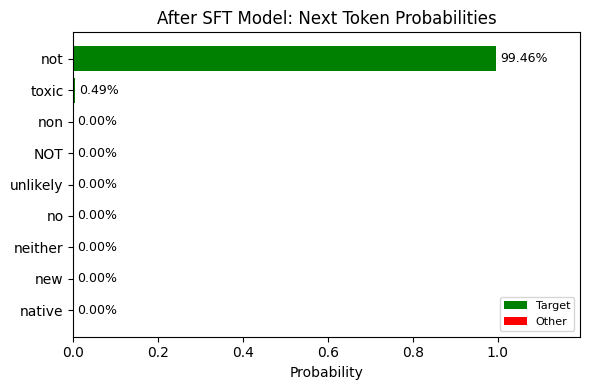

SFT model: P(toxic)=0.0049, P(not)=0.9946, sum=0.9995


In [189]:
from src.scoring import plot_top_token_probs

sft_base = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    quantization_config=bnb_config,
    device_map='auto'
)
sft_model = PeftModel.from_pretrained(sft_base, config.sft_adapter_path)

# Test on sample prompt
sample_prompt = eval_sft[0]['prompt']

# Base model
fig = plot_top_token_probs(sft_model, tokenizer, sample_prompt, title="After SFT Model: Next Token Probabilities")
plt.savefig(f'{config.figures_dir}/sft_token_probs.png', dpi=150)
plt.show()

# Print the probability of labels
p_toxic, p_not = get_label_probs(sft_model, tokenizer, sample_prompt)
print(f"SFT model: P(toxic)={p_toxic:.4f}, P(not)={p_not:.4f}, sum={p_toxic+p_not:.4f}")

clear_memory()

#### Log-Odds

After SFT, probability mass concentrates almost entirely on the two label token under the training prompt:
$$ P(\text{"toxic"}\mid prompt) + P(\text{"not toxic"}\mid prompt) \approx 1 $$

This is not explicity enforced buy the loss, but is a direct consequence of training on two labels. Under this prompt, the model now behaves like a binary classifier, with other continuation receiving negligible probability. If we did not do SFT before, DPO would be inefficient because its job isn't to learn the statistical probability of seeing "toxic" vs "not toxic", its objective is to increase the log-probability difference between the two tokens.

A useful consequence of this is that the log-probability difference between the two labels can be interpreted as a log-odds score for this interface. I later discuss why extending this interpretation beyond the training prompt can be misleading in calibration analysis.

## DPO Training
DPO has a nice side effect of optimizing the same log-prob difference we use for scoring. It's also sample and compute efficient. $$\text{score} = log(P(\text{toxic}\mid \text{train})) - log(P(\text{not toxic}\mid \text{train}))$$


In [20]:
# Load DPO datasets
train_dpo = load_dataset('json', data_files='data/civil_comments_dpo_train.jsonl', split='train')
eval_dpo = load_dataset('json', data_files='data/civil_comments_dpo_eval.jsonl', split='train')

print(f"DPO train: {len(train_dpo):,} | DPO eval: {len(eval_dpo):,}")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

DPO train: 10,000 | DPO eval: 1,000


In [30]:
clear_memory()

# let's do calculations in 4bit to conserve memory
bnb_config = BitsAndBytesConfig(
    load_in_4bit=config.load_in_4bit,
    bnb_4bit_quant_type=config.bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=config.bnb_4bit_use_double_quant
)

# Load SFT model as starting point for DPO
sft_base = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    quantization_config=bnb_config,
    device_map='auto',
    dtype=torch.float16
)

sft_base = prepare_model_for_kbit_training(sft_base)
sft_model = PeftModel.from_pretrained(sft_base, config.sft_adapter_path, is_trainable=True)
sft_model.print_trainable_parameters()

tokenizer = AutoTokenizer.from_pretrained(config.model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

trainable params: 3,407,872 || all params: 1,239,222,272 || trainable%: 0.2750


I set the beta = 0.1 to study how aggressive DPO reshapes decision margins on top of an already strong SFT signal.

In [22]:
# DPO config
dpo_config = DPOConfig(
    output_dir=config.dpo_output_dir,
    num_train_epochs=config.dpo_epochs,
    per_device_train_batch_size=config.dpo_batch_size,
    gradient_accumulation_steps=config.dpo_gradient_accumulation,
    learning_rate=config.dpo_learning_rate,
    beta=config.dpo_beta,  # KL penalty
    max_length=config.dpo_max_length,
    max_prompt_length=config.dpo_max_prompt_length,
    logging_steps=10,
    save_steps=100,
    fp16=True,
    gradient_checkpointing=False,
    report_to='none',
)

dpo_trainer = DPOTrainer(
    model=sft_model,
    ref_model=None,  # Uses initial SFT weights as reference
    args=dpo_config,
    train_dataset=train_dpo,
    eval_dataset=eval_dpo,
    processing_class=tokenizer,
)

print(f"Beta (KL penalty): {config.dpo_beta}")

Extracting prompt in train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Extracting prompt in eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Applying chat template to eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Beta (KL penalty): 0.1


In [143]:
clear_memory()

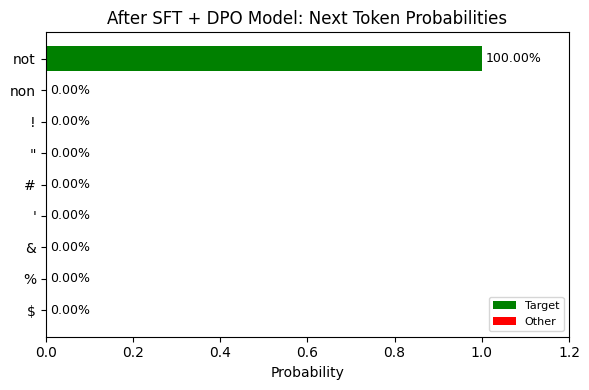

AFter SFT + DPO model: P(toxic)=0.0000, P(not)=1.0000, sum=1.0000


In [224]:
from src.scoring import plot_top_token_probs

sft_base = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    quantization_config=bnb_config,
    device_map='auto'
)
dpo_model = PeftModel.from_pretrained(sft_base, config.dpo_adapter_path)

# Test on sample prompt
sample_prompt = eval_sft[0]['prompt']

# Plot
fig = plot_top_token_probs(dpo_model, tokenizer, sample_prompt, title="After SFT + DPO Model: Next Token Probabilities")
plt.savefig(f'{config.figures_dir}/dpo_token_probs.png', dpi=300)
plt.show()

# Print the probability of labels
p_toxic, p_not = get_label_probs(sft_model, tokenizer, sample_prompt)
print(f"AFter SFT + DPO model: P(toxic)={p_toxic:.4f}, P(not)={p_not:.4f}, sum={p_toxic+p_not:.4f}")
clear_memory()

Right after SFT (and early in DPO), the distribution is close to log-odds. After extended DPO training, this is no longer true and the model concentrates nearly all the probability mass on "not" instead of saying "toxic" with the next probability. The next probable logits are mostly punctuation now. DPO mainly reduces uncertainty around borderline cases, increasing separation between toxic and non-toxic content while leaving overall accuracy largely unchanged.

# Evaluation

When I first evaluated the model, I used only 1000 samples and many of the curves had low resolution especially on the left side of the PR diagram which was jagged. This makes sense because represents the high score threshold areas, there would not be as many data points since only the most toxic examples are flagged. I've done some experimenting and found 10k samples works fairly well with diminishing returns past 20k samples.

Let's also make sure we get the test data ready.

In [75]:
import src.scoring
# Load eval data
test = load_dataset('json', data_files='data/civil_comments_test.jsonl', split='train')

Now, we will evaluate our models one at a time, making sure to save the data and clear the memory when we are done with each model.

In [25]:
# Quantize in 4 bits
bnb_config = BitsAndBytesConfig(
    load_in_4bit=config.load_in_4bit,
    bnb_4bit_quant_type=config.bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=config.bnb_4bit_use_double_quant
)

In [26]:
# Evaluate BASE model first
clear_memory()

print("Evaluating BASE model...")
base_model = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    quantization_config=bnb_config,
    device_map='auto'
)
tokenizer = AutoTokenizer.from_pretrained(config.model_id)

df_base = evaluate_model(base_model, tokenizer, test, max_samples=config.test_samples)
df_base.to_csv('results/base_results.csv', index=False)

del base_model
clear_memory()

Evaluating BASE model...


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████| 40000/40000 [1:07:31<00:00,  9.87it/s]


In [27]:
# Evaluate SFT model
print("Evaluating SFT model...")

sft_base = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    quantization_config=bnb_config,
    device_map='auto'
)
sft_model = PeftModel.from_pretrained(sft_base, config.sft_adapter_path)

df_sft = evaluate_model(sft_model, tokenizer, test, max_samples=config.test_samples)
df_sft.to_csv('results/sft_results.csv', index=False)

del sft_base, sft_model
clear_memory()

Evaluating SFT model...


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████| 40000/40000 [1:28:38<00:00,  7.52it/s]


In [28]:
# Evaluate DPO model
clear_memory()

print("Evaluating DPO model...")
dpo_base = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    quantization_config=bnb_config,
    device_map='auto'
)
dpo_model = PeftModel.from_pretrained(dpo_base, config.dpo_adapter_path)

df_dpo = evaluate_model(dpo_model, tokenizer, test, max_samples=config.test_samples)
df_dpo.to_csv('results/dpo_results.csv', index=False)

del dpo_base, dpo_model
clear_memory()

Evaluating DPO model...


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████| 40000/40000 [1:28:24<00:00,  7.54it/s]


## Analysis

For analysis we will first look at some PR, ROC

In [12]:
import src.scoring

In [7]:
# Load in saved Dataframes
df_base = pd.read_csv('results/base_results.csv')
df_sft = pd.read_csv('results/sft_results.csv')
df_dpo = pd.read_csv('results/dpo_results.csv')

The compute_metrics function puts our data into different sklearn functions that will help us calculate our PR and ROC curves easily by sweeping through thresholds of our log-probability scores.

In [14]:
from src.scoring import compute_metrics
# Compute metrics, Calculates PR-AUC, ROC-AUC, curves and operating points
metrics_base = compute_metrics(df_base)
metrics_sft = compute_metrics(df_sft)
metrics_dpo = compute_metrics(df_dpo)

Let's see how the functions look like:

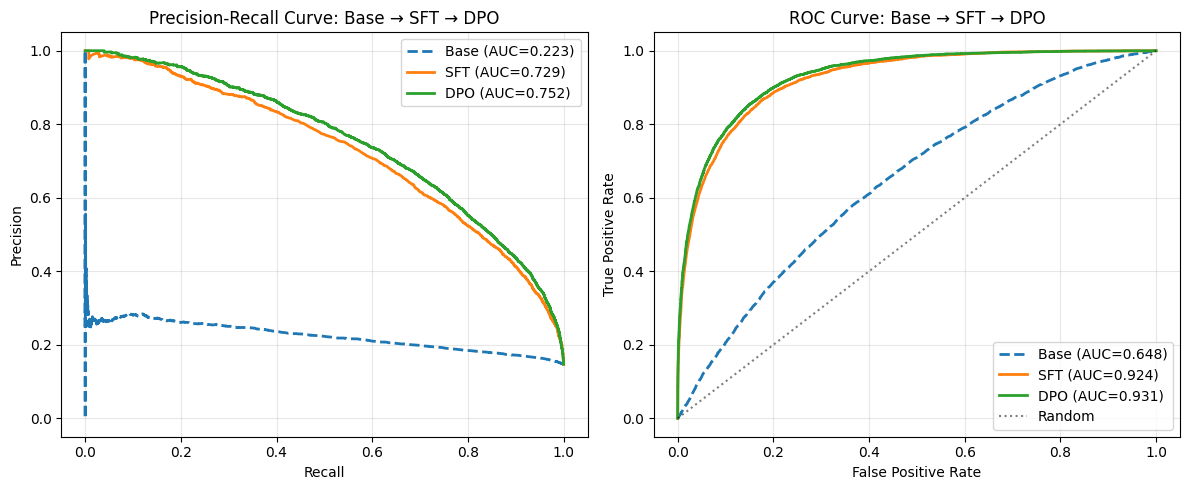

In [193]:
# Plot PR and ROC curves
fig = plot_all_curves(metrics_base, metrics_sft, metrics_dpo)
plt.savefig(f'{config.figures_dir}/all_curves.png', dpi=300)
plt.show()

Looking at both curves the base model went from being useless at classifying our definition of toxic to having a huge jump in area with just the SFT training. Adding DPO has refined the model and added a small boost to precision/recall and TP/FP trade offs on all possible thresholds.

Let's see how much SFT and DPO contributed to the trade offs at specific thresholds.

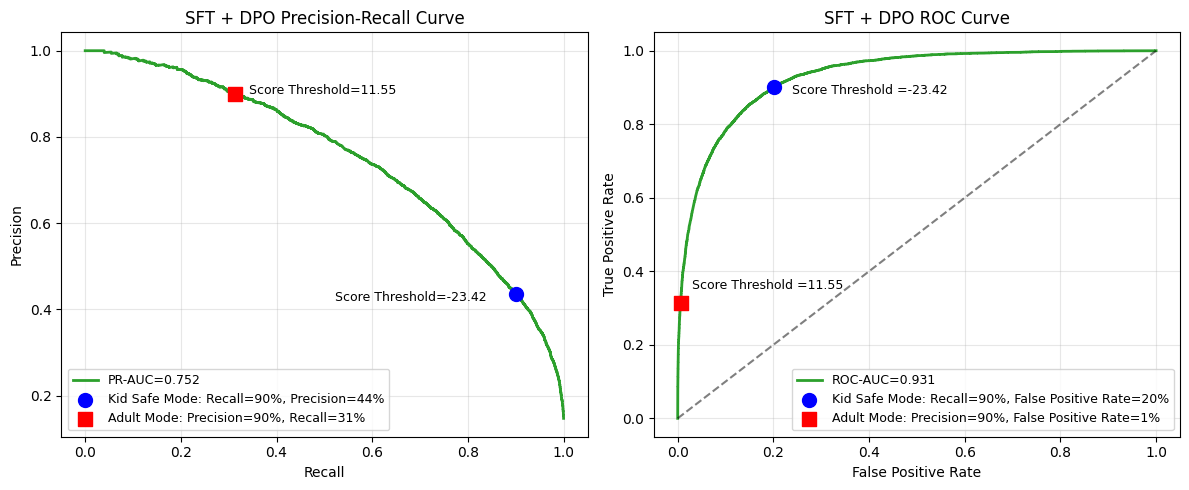

In [187]:
from src.scoring import plot_curves_with_operating_points

fig = src.scoring.plot_curves_with_operating_points(metrics_dpo, 'SFT + DPO ')
plt.savefig(f'{config.figures_dir}/DPO_operating_curves.png', dpi=300)
plt.show()

### Defining Operating Modes <a id="kidsafemode"></a>

1. **Kid Safe Mode (90% recall)**: Minimize mixed toxicity. Catches 90% of toxic comments, but 56% of flags are false positives. Definitely a setting Roblox would like.
2. **Adult Mode (90% precision)**: Avoid unnecessary censorship. Is correct about toxic comments 90% of the time but only catches 31% of toxic content.

The score threshold gap (${\Delta} \approx 35$ log-probability) between the modes requires $e^{\Delta} \approx e^{35}\sim 10^{15}$ higher confidence before flagging. Changing the threshold allows us to use the same model but with a different policy.

**Note: Toxic comments defined as dataset score ≥ 0.3**

**Precision at Fixed Recall**
| Recall | Base | SFT | DPO |
|--------|------|-----|-----|
| 95% | 17% | 33% | 35% |
| 90% | 17% | 41% | 44% |
| 80% | 19% | 52% | 55% |

**Recall at Fixed Precision**
| Precision | Base | SFT | DPO |
|-----------|------|-----|-----|
| 95% | 0% | 17% | 21% |
| 90% | 0% | 26% | 31% |
| 80% | 0% | 46% | 51% |

On Kid Safe Mode (90% recall), DPO gains +2.4% precision over SFT.

On Adult Mode (90% precision), DPO gains +5.4% recall over SFT.

The base model is unable to detect any comments with a Precision above ~30%. Our score compares log P("toxic") vs log P("not toxic") and favors confidence. This indicates that the base model assigns similar probability to both labels, so the log-probability difference is noise. SFT concentrates probability on our labels, making the score meaningful.

### Score Distributions

Mean shift for TOXIC comments:     +1.9166
Mean shift for NOT TOXIC comments: -25.3534

Ideal: Toxic shifts positive, Not Toxic shifts negative


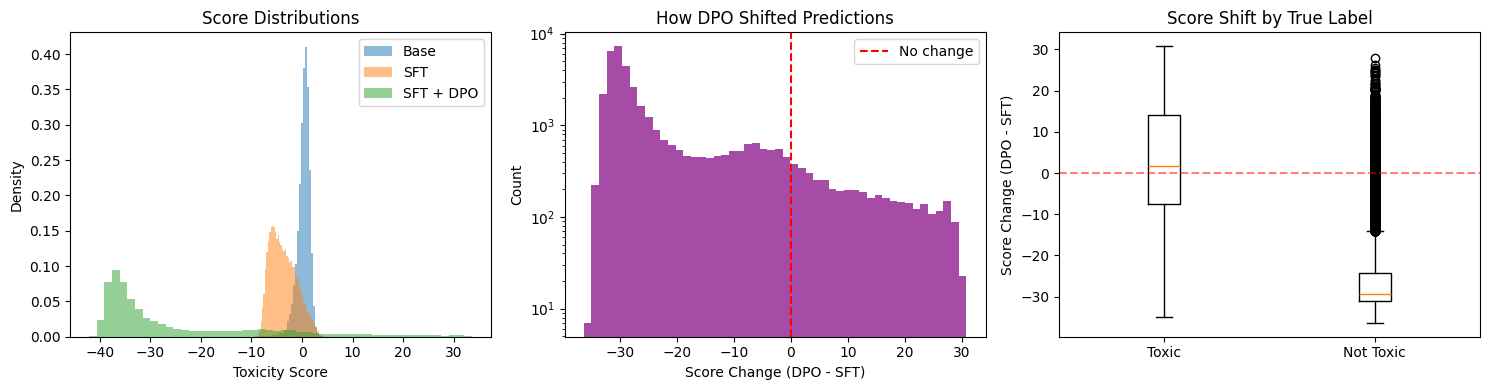

In [196]:
from src.scoring import plot_all_calibration_curves
import importlib
import src.scoring

src.scoring.plot_score_distributions(df_base, df_sft, df_dpo)
plt.savefig(f'{config.figures_dir}/score_distributions.png', dpi=300)

plt.show()

DPO helped the model categorize "toxic" comments e^2 times more confidently and "not toxic" comments e^25 times more confidently. DPO primarily learned to be much more confident about what isn't toxic. This reduces false positives more than it reduces false negatives.

Comparing the original dataset toxicity scores with the model scores after SFT and DPO, the overall shape of the distribution remains similar. Preference optimization largely preserves the underlying ordering of examples, acting as a mostly monotonic remapping rather than learning a new notion of toxicity. DPO primarily increases margin and confidence, pushing ambiguous examples away from the decision boundary without reshuffling the extremes.

### Calibration

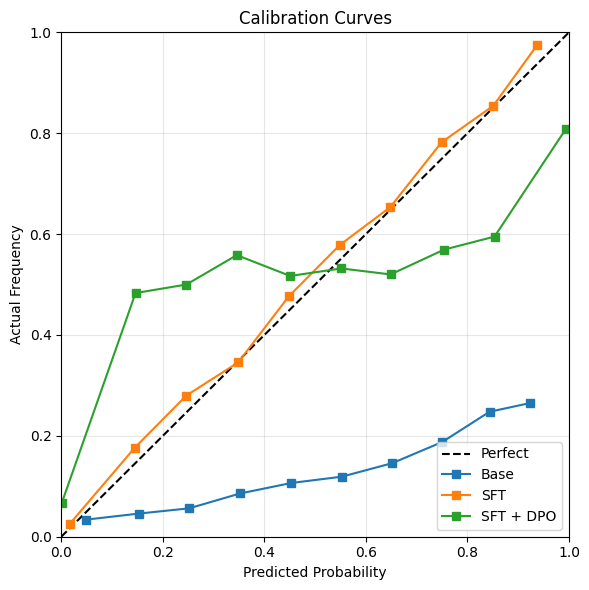

In [186]:
from src.scoring import plot_all_calibration_curves

plot_all_calibration_curves(df_base, df_sft, df_dpo, n_bins=10)
plt.savefig(f'{config.figures_dir}/calibration_curves.png', dpi=300)
plt.show()

SFT produces well-calibrated probabilities. DPO sacrifices calibration for better ranking, it optimizes preference margin, teaching it more than the underlying statistics between words. This is evident when the DPO Actual Frequency hovers around 50% but this is not a problem with our log-probability scoring.

For deployment, use the score for ranking/thresholding, not as a literal probability. This is why we have to use DPO as a ranker.

**Calibration Note:** DPO improves ranking but degrades probability calibration. Scores should be interpreted as decision margins, not probabilities.

### Cost Analysis

In [184]:
from src.scoring import compare_costs
compare_costs(df_sft, df_dpo, cost_ratios=[(10, 1), (5, 1), (1, 1), (1, 5)])


COST-SENSITIVE THRESHOLD ANALYSIS

FN:FP cost ratio 10:1
  SFT optimal: threshold=-2.562, cost=13375
  DPO optimal: threshold=-26.984, cost=12501
  Cost reduction: 874 (6.5%)

FN:FP cost ratio 5:1
  SFT optimal: threshold=-2.094, cost=9952
  DPO optimal: threshold=-16.672, cost=9438
  Cost reduction: 514 (5.2%)

FN:FP cost ratio 1:1
  SFT optimal: threshold=-0.141, cost=3761
  DPO optimal: threshold=-1.000, cost=3613
  Cost reduction: 148 (3.9%)

FN:FP cost ratio 1:5
  SFT optimal: threshold=1.687, cost=5154
  DPO optimal: threshold=15.290, cost=4955
  Cost reduction: 199 (3.9%)


,fn_cost,fp_cost,sft_threshold,sft_cost,dpo_threshold,dpo_cost
0,10,1,-2.562012,13375.0,-26.984356,12501.0
1,5,1,-2.093933,9952.0,-16.671857,9438.0
2,1,1,-0.140625,3761.0,-1.000119,3613.0
3,1,5,1.687378,5154.0,15.290259,4955.0


| FN:FP Ratio | Use Case | DPO Cost Reduction |
|-------------|----------|-------------------|
| 10:1 | Kid-safe (missed toxicity is bad) | 6.5% |
| 5:1 | Moderate | 5.2% |
| 1:1 | Balanced | 3.9% |
| 1:5 | Free speech (false reports are bad) | 3.9% |

DPO reduces costs at every operating point with the largest gains found when missed toxicity is expensive. DPO's most optimal costs are at negative scores. This aligns with our observations of our model becoming more confident about comments that are "not toxic" in the score distribution, leading to lower false negatives.

In [199]:
from src.scoring import find_biggest_changes
import importlib
import src.scoring

find_biggest_changes(df_sft, df_dpo, n=10)


TOP 10 EXAMPLES WHERE DPO CHANGED MOST

✓ True: not toxic | SFT: -2.92 → DPO: -39.28 (↓ less toxic)
   Where did the policy come from? Was it written by the VP of in-flight services, or was she simply interpreting / publicizing the existing policy? If s...

✓ True: not toxic | SFT: -4.52 → DPO: -40.09 (↓ less toxic)
   With due respect you have no idea of what you are talking about. There is NO competition across state lines. Alaska has only one provider and our prem...

✓ True: not toxic | SFT: -4.34 → DPO: -39.56 (↓ less toxic)
   So are you saying you support his "right" to allow the trees and brush damage the utility lines in an easement? Wait until your electricity goes out b...

✓ True: not toxic | SFT: -3.25 → DPO: -38.41 (↓ less toxic)
   You must not have read the article.  The Assembly passed an ordinance barring any consumption, sale, or trading at it's Municipal properties.  It's be...

✓ True: not toxic | SFT: -3.70 → DPO: -38.84 (↓ less toxic)
   Yes because most on your

,text,true_label,score_sft,score_dpo,score_diff,abs_diff
23840,Where did the policy come from? Was it written...,0,-2.921570,-39.281209,-36.359640,36.359640
9952,With due respect you have no idea of what you ...,0,-4.516151,-40.093687,-35.577536,35.577536
23130,"So are you saying you support his ""right"" to a...",0,-4.341949,-39.562431,-35.220482,35.220482
32501,You must not have read the article. The Assem...,0,-3.250549,-38.406214,-35.155665,35.155665
39834,Yes because most on your list are nothing burg...,0,-3.703171,-38.843693,-35.140522,35.140522
8897,"Thanks, Anon. I think the Church has yet to re...",0,-4.937817,-40.062456,-35.124640,35.124640
37729,I know this story is dated but it still rankle...,0,-5.000763,-40.031183,-35.030420,35.030420
1063,No? There are at least 10 people in that secon...,0,-4.373642,-39.374945,-35.001303,35.001303
32274,"Yes, Sue Wolling is one of the city staff's fa...",0,-4.748817,-39.749959,-35.001141,35.001141
17976,Clearly you have never used SWA. First 15 to b...,0,-3.156738,-38.156149,-34.999411,34.999411


Again, DPO increases the model's confidence in its labels by shifting the distribution of scores leftward.

### Failure Analysis

In [15]:
from datasets import load_dataset
from src.scoring import failure_analysis

raw = load_dataset('google/civil_comments', split='test')
def failure_analysis(df, threshold, n=5, raw_dataset=None):
    """
    Find high-confidence errors: false positives and false negatives.
    
    Usage:
        from datasets import load_dataset
        raw = load_dataset('google/civil_comments', split='validation')
        fp, fn = failure_analysis(df_dpo, metrics_dpo['kid_safe_threshold'], raw_dataset=raw)
    """
    y_pred = (df['score'].values >= threshold).astype(int)
    df = df.copy()
    df['pred'] = y_pred
    
    # Build lookup dict for original scores (full text as key)
    raw_lookup = {}
    if raw_dataset is not None:
        for ex in raw_dataset:
            raw_lookup[ex['text']] = ex['toxicity']
    
    def get_orig_score(text):
        if raw_dataset is None:
            return "N/A"
        # Try exact match first
        if text in raw_lookup:
            return f"{raw_lookup[text]:.2f}"
        # Try partial match
        for raw_text, tox in raw_lookup.items():
            if text in raw_text or raw_text in text:
                return f"{tox:.2f}"
        return "N/A"
    
    # False positives: predicted toxic, actually not toxic
    false_positives = df[(df['true_label'] == 0) & (df['pred'] == 1)].nlargest(n, 'score')
    
    # False negatives: predicted not toxic, actually toxic
    false_negatives = df[(df['true_label'] == 1) & (df['pred'] == 0)].nsmallest(n, 'score')
    
    print("\n" + "="*60)
    print("FAILURE ANALYSIS")
    print("="*60)
    
    print(f"\n--- FALSE POSITIVES (flagged but not toxic) ---")
    for _, row in false_positives.iterrows():
        orig = get_orig_score(row['text'])
        print(f"\nModel Score: {row['score']:.2f} | Original Toxicity: {orig}")
        print(f"   {row['text'][:1000]}...")
    
    print(f"\n--- FALSE NEGATIVES (missed toxic content) ---")
    for _, row in false_negatives.iterrows():
        orig = get_orig_score(row['text'])
        print(f"\nModel Score: {row['score']:.2f} | Original Toxicity: {orig}")
        print(f"   {row['text'][:1000]}...")
    
    return false_positives, false_negatives
fp, fn = failure_analysis(df_dpo, metrics_dpo['kid_safe_threshold'], raw_dataset=raw)


FAILURE ANALYSIS

--- FALSE POSITIVES (flagged but not toxic) ---

Model Score: 29.84 | Original Toxicity: 0.18
   Colonel Sanders aka Dimwit.  How's that?...

Model Score: 28.76 | Original Toxicity: 0.20
   I'm waiting for the column on Mika and Joe calling the President "moron", "idiot", "mentally unstable" and "shmuck". Will I be waiting long?...

Model Score: 27.76 | Original Toxicity: 0.17
   Pollution EXISTS, that is not a joke - the fraud is that we are being told to pay for them to continue while they can create shell companies and dump MORE toxic waste in waters/lands and in out backyard - literally.

if you think the bombing non-stop for years in countries is not cooking the earth, then you are severely stupid. They are not using perfume as bombs....

Model Score: 27.37 | Original Toxicity: 0.17
   Wrong again - Also, because you say "my bad" doesn't mean your stu*pidity is excused....

Model Score: 27.31 | Original Toxicity: 0.28
   Dumb French Liberals.....In 20 years they

### Failure Modes

**False Positives** (flagged but labeled non-toxic):

| Comment | Model | Original | Analysis |
|---------|-------|----------|----------|
| "your stu*pidity is excused" | 27.4 | 0.16 | Toxic, mislabeled |
| "Colonel Sanders aka Dimwit" | 29.8 | 0.18 | Toxic, mislabeled |
| "Dumb French Liberals..." | 27.3 | 0.28 | Borderline |
| "Pollution EXISTS...severely stupid" | 27.8 | 0.17 | Triggered by "stupid" |

Most false positives contain clear insults that annotators scored too low. The model may be outperforming the labels.

**False Negatives** (missed but labeled toxic):

| Comment | Model | Original | Analysis |
|---------|-------|----------|----------|
| "not a legal thing yet..." | -40.7 | 0.30 | Benign, mislabeled |
| "The Changs let the theatre..." | -38.9 | 0.40 | Critical but mild |
| European wheat/Africa discussion | -38.8 | 0.40 | Long, requires context |
| "Go look it up in the dictionary" | -38.1 | 0.30 | Condescending, borderline |

False negatives cluster at 0.30-0.40 - the noisy boundary region.

Note: The score reflects relative log-odds, not absolute confidence. A low score means non-toxic dominates, but doesn't mean zero toxic signal.

Takeaway: For kid safe mode, these errors are acceptable. False positives are arguably correct, false negatives are mild.

Other potential failure modes:
- Quoted toxicity ("He said I was stupid")
- Sarcasm misread as toxic
- Profanity in non-toxic context
- Long comments where toxic content is buried

In [27]:
clear_memory()

import src.scoring as scoring

bnb_config = BitsAndBytesConfig(
    load_in_4bit=config.load_in_4bit,
    bnb_4bit_quant_type=config.bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=config.bnb_4bit_use_double_quant
)

tokenizer = AutoTokenizer.from_pretrained(config.model_id, use_fast=True)
sft_base = AutoModelForCausalLM.from_pretrained(
    config.model_id,
    quantization_config=bnb_config,
    device_map='auto'
)
dpo_model = PeftModel.from_pretrained(sft_base, config.dpo_adapter_path)

# Then analyze probabilities for false positives
print("\n=== FALSE POSITIVE PROBABILITIES ===")
scoring.analyze_failure_probs(dpo_model, tokenizer, fp)

# And false negatives
print("\n=== FALSE NEGATIVE PROBABILITIES ===")
scoring.analyze_failure_probs(dpo_model, tokenizer, fn)

clear_memory()


=== FALSE POSITIVE PROBABILITIES ===

Score: 29.84
P(toxic): 0.977539 | P(not toxic): 0.000000 | Ratio: inf
   Colonel Sanders aka Dimwit.  How's that?...

Score: 28.76
P(toxic): 0.992676 | P(not toxic): 0.000000 | Ratio: inf
   I'm waiting for the column on Mika and Joe calling the President "moron", "idiot", "mentally unstabl...

Score: 27.76
P(toxic): 0.977051 | P(not toxic): 0.000000 | Ratio: inf
   Pollution EXISTS, that is not a joke - the fraud is that we are being told to pay for them to contin...

Score: 27.37
P(toxic): 0.999512 | P(not toxic): 0.000000 | Ratio: inf
   Wrong again - Also, because you say "my bad" doesn't mean your stu*pidity is excused....

Score: 27.31
P(toxic): 0.995117 | P(not toxic): 0.000000 | Ratio: inf
   Dumb French Liberals.....In 20 years they will all be b owing toward mecca and praying to Allah....

=== FALSE NEGATIVE PROBABILITIES ===

Score: -40.69
P(toxic): 0.000000 | P(not toxic): 1.000000 | Ratio: 0.00
   not a legal thing yet, but it is the 

Many of the False Positives are arguably correct and false negatives are mild. Probability analysis confirms the model is confident in these cases, not uncertain, suggesting label noise.

**Limitation:** DPO produces overconfident predictions (P ≈ 0 or 1, rarely in between). This is fine for ranking or thresholding but means the raw probabilities shouldn't be interpreted as calibrated confidence.

## Summary
- SFT teaches the task and DPO refines the ranking. The result is a continuous score that can be thresholded for different policies such as kid-safe or adult mode without retraining.
- Two interpretable parameters control the system: the initial labeling threshold of 0.3 and the score threshold used at inference time. Both numbers are interpretable, auditable, and easily adjustable.

## Future Work

- Custom CUDA kernels for efficiency
- Multi-label toxicity (threat, insult, obscenity)
- Compare to classification head baseline

## Reproducibility

All results in this report were generated by running the notebook `RLHF Content Moderation.ipynb` top-to-bottom with the provided configuration. A fixed random seed is used for all experiments. Some training cells were set to RAW to prevent retraining.